# Лабораторна робота 5 (VAR 3)

Для `N=2`: `N % 3 = 2` 


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio

np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')
pio.renderers.default = 'vscode'


In [4]:
SEED = 42
rng = np.random.default_rng(SEED)
N_TRAIN = 120
N_TEST_PER_CLASS = 120

# 3D, uniform distributions
specs = {
    "Клас 1": {"low": np.array([-7.5, -6.0, -4.0]), "high": np.array([-1.0, 1.0, 2.0]), "color": "tab:red"},
    "Клас 2": {"low": np.array([0.5, -5.5, -3.5]),  "high": np.array([7.0, 1.5, 2.5]), "color": "tab:blue"},
    "Клас 3": {"low": np.array([-2.0, 2.5, 0.0]),   "high": np.array([4.5, 8.5, 6.5]), "color": "tab:green"},
}

train = {cn: rng.uniform(s['low'], s['high'], size=(N_TRAIN,3)) for cn, s in specs.items()}
centroids = {cn: pts.mean(axis=0) for cn, pts in train.items()}

print('Centroids:')
for cn, c in centroids.items():
    print(cn, np.round(c,4))


Centroids:
Клас 1 [-4.1839 -2.6461 -1.0441]
Клас 2 [ 3.8081 -1.9523 -0.3216]
Клас 3 [1.1535 5.3684 3.237 ]


## Кандидатні прямі і критерій

Варіант для вибору прямої (за умовою):
- мінімізувати суму відстаней всіх навчальних точок до прямої.

Тобто для кожної кандидатної прямої рахуємо ортогональну відстань від кожної навчальної точки до цієї прямої
і обираємо пряму з мінімальною сумою цих відстаней.

Додатково перевіряємо ще один критерій: максимізувати середньоквадратичну попарну відстань між точками в 1D-проєкції на пряму.


In [5]:
class_names = list(specs.keys())
pairs = [("Клас 1", "Клас 2"), ("Клас 2", "Клас 3"), ("Клас 1", "Клас 3")]


def make_line(a, b):
    ca, cb = centroids[a], centroids[b]
    d = cb - ca
    u = d / np.linalg.norm(d)
    return {'a': a, 'b': b, 'origin': ca, 'u': u}


def proj(points, line):
    return (points - line['origin']) @ line['u']


def point_to_line_dist(points, line):
    # Orthogonal distance from 3D points to a 3D line
    v = points - line['origin']
    t = v @ line['u']
    p_on_line = line['origin'][None, :] + t[:, None] * line['u'][None, :]
    return np.linalg.norm(points - p_on_line, axis=1)


def mean_pairwise_squared_distance(values):
    # Mean squared pairwise distance in 1D projection
    diffs = values[:, None] - values[None, :]
    return float(np.mean(diffs ** 2))


lines = {f"{a}-{b}": make_line(a, b) for a, b in pairs}


stats = {}
for lname, line in lines.items():
    all_dists = []
    all_proj = []
    for cn in class_names:
        points = train[cn]
        all_dists.append(point_to_line_dist(points, line))
        all_proj.append(proj(points, line))
    all_dists = np.concatenate(all_dists)
    all_proj = np.concatenate(all_proj)
    stats[lname] = {
        'sum_dist': float(all_dists.sum()),
        'mean_dist': float(all_dists.mean()),
        'proj_msd': mean_pairwise_squared_distance(all_proj),
    }

print('Criterion values:')
for lname, s in stats.items():
    print(
        lname,
        f"sum_dist={s['sum_dist']:.4f}",
        f"mean_dist={s['mean_dist']:.4f}",
        f"proj_msd={s['proj_msd']:.4f}",
    )


Criterion values:
Клас 1-Клас 2 sum_dist=1639.3456 mean_dist=4.5537 proj_msd=31.0353
Клас 2-Клас 3 sum_dist=1560.6149 mean_dist=4.3350 proj_msd=35.2145
Клас 1-Клас 3 sum_dist=1373.2384 mean_dist=3.8146 proj_msd=44.5884


In [ ]:
# minimize total distance from all training points to the line
keys = list(stats.keys())
sum_vals = np.array([stats[k]['sum_dist'] for k in keys])
proj_vals = np.array([stats[k]['proj_msd'] for k in keys])

best_name = keys[int(np.argmin(sum_vals))]
best_line = lines[best_name]

best_proj_name = keys[int(np.argmax(proj_vals))]

print('Selection by criterion: minimize total distance to line')
for k in keys:
    print(k, f"sum_dist={stats[k]['sum_dist']:.4f}", f"proj_msd={stats[k]['proj_msd']:.4f}")
print('Best line:', best_name)
print('Best line by projected mean squared distance:', best_proj_name)


Selection by criterion: minimize total distance to line
Клас 1-Клас 2 sum_dist=1639.3456 proj_msd=31.0353
Клас 2-Клас 3 sum_dist=1560.6149 proj_msd=35.2145
Клас 1-Клас 3 sum_dist=1373.2384 proj_msd=44.5884
Best line: Клас 1-Клас 3
Best line by projected mean squared distance: Клас 1-Клас 3


## Класифікація за обраною прямою


In [ ]:
#  Клас 1-Клас 3 пряма є найкращою за обома критеріями, тому вибираємо її як найкращу.


cent_proj = {cn: float(proj(centroids[cn][None,:], best_line)[0]) for cn in class_names}


def classify(x):
    tx = float(proj(x[None,:], best_line)[0])
    pred = min(class_names, key=lambda cn: abs(tx - cent_proj[cn]))
    return pred, tx

X_test = []
y_test = []
for cn, s in specs.items():
    pts = rng.uniform(s['low'], s['high'], size=(N_TEST_PER_CLASS, 3))
    X_test.append(pts)
    y_test += [cn] * N_TEST_PER_CLASS
X_test = np.vstack(X_test)
y_test = np.array(y_test)

pred, tproj = [], []
for x in X_test:
    p, t = classify(x)
    pred.append(p)
    tproj.append(t)
pred = np.array(pred)

acc = float((pred == y_test).mean())
print(f'Accuracy: {acc:.4f}')

print() 
print('Перші 10 прогнозів:')
print(' idx | true   | pred   | t_proj')
print('-'*34)
for i in range(10):
    print(f"{i+1:4d} | {y_test[i]:6s} | {pred[i]:6s} | {tproj[i]:7.3f}")


Accuracy: 0.8639

Перші 10 прогнозів:
 idx | true   | pred   | t_proj
----------------------------------
   1 | Клас 1 | Клас 2 |   2.484
   2 | Клас 1 | Клас 2 |   4.369
   3 | Клас 1 | Клас 1 |   2.318
   4 | Клас 1 | Клас 1 |  -1.078
   5 | Клас 1 | Клас 1 |  -1.678
   6 | Клас 1 | Клас 1 |  -0.927
   7 | Клас 1 | Клас 1 |  -1.687
   8 | Клас 1 | Клас 1 |   1.967
   9 | Клас 1 | Клас 1 |  -0.571
  10 | Клас 1 | Клас 1 |   1.639


In [8]:
# confusion matrix
idx = {n:i for i,n in enumerate(class_names)}
cm = np.zeros((3,3), dtype=int)
for t, p in zip(y_test, pred):
    cm[idx[t], idx[p]] += 1

print('Confusion matrix (rows=true, cols=pred):')
print('       ', class_names)
for i, n in enumerate(class_names):
    print(f'{n:>7s}', cm[i])


Confusion matrix (rows=true, cols=pred):
        ['Клас 1', 'Клас 2', 'Клас 3']
 Клас 1 [105  15   0]
 Клас 2 [17 93 10]
 Клас 3 [  0   7 113]


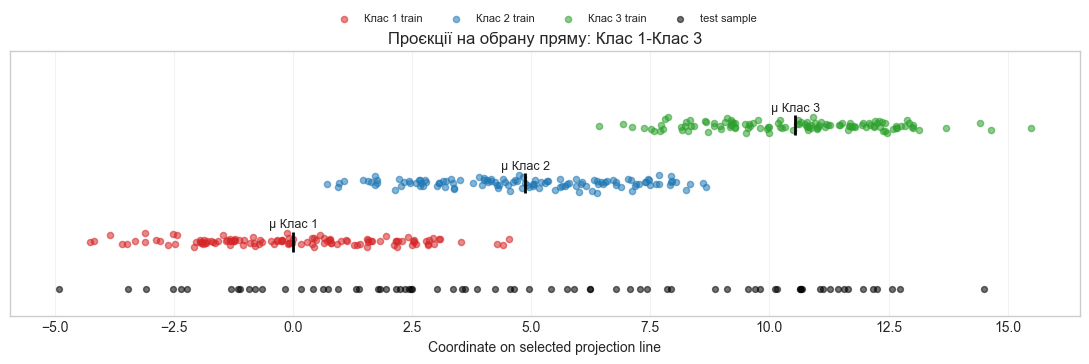

In [9]:
# 1D strip visualization on selected line
fig, ax = plt.subplots(figsize=(11, 3.8))

# Place each class on its own horizontal band to avoid overlap
band_y = {cn: i * 0.22 for i, cn in enumerate(class_names)}

for cn in class_names:
    t = proj(train[cn], best_line)
    y = np.full_like(t, band_y[cn]) + rng.normal(0, 0.012, size=len(t))
    ax.scatter(t, y, s=20, alpha=0.55, color=specs[cn]['color'], label=f'{cn} train')
    ax.scatter(cent_proj[cn], band_y[cn], s=220, marker='|', color='black', linewidths=2.0)
    ax.text(cent_proj[cn], band_y[cn] + 0.055, f'μ {cn}', ha='center', fontsize=9)

sel = np.arange(0, len(X_test), max(1, len(X_test)//70))
test_y = np.full(len(sel), -0.18)
ax.scatter(np.array(tproj)[sel], test_y, s=18, color='black', alpha=0.55, label='test sample')

ax.set_yticks([])
ax.set_xlabel('Coordinate on selected projection line')
ax.set_title(f'Проєкції на обрану пряму: {best_name}')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), fontsize=8, ncol=4, frameon=False)
ax.set_ylim(-0.28, max(band_y.values()) + 0.28)
ax.grid(True, axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
import plotly.graph_objects as go
from IPython.display import display

sample_n = 18
line = best_line
o = line['origin']
u = line['u']
plotly_colors = {
    'tab:red': '#d62728',
    'tab:blue': '#1f77b4',
    'tab:green': '#2ca02c',
}

# Small sample for readable 3D connectors
sample_idx = np.arange(0, len(X_test), max(1, len(X_test)//sample_n))[:sample_n]
Xs = X_test[sample_idx]
ys = y_test[sample_idx]

ts = proj(Xs, line)
Ps = o[None, :] + ts[:, None] * u[None, :]   # projected 3D points on the line

t_min = float(min(np.min(proj(X_test, line)), min(cent_proj.values())) - 1.0)
t_max = float(max(np.max(proj(X_test, line)), max(cent_proj.values())) + 1.0)
line_points = np.vstack([o + t_min * u, o + t_max * u])

fig3d = go.Figure()

for cn in class_names:
    pts = train[cn]
    pcolor = plotly_colors[specs[cn]['color']]
    fig3d.add_trace(
        go.Scatter3d(
            x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
            mode='markers',
            name=f'{cn} train',
            marker=dict(size=3.5, color=pcolor),
            opacity=0.22,
            hovertemplate=f'{cn} train<extra></extra>',
            showlegend=True,
        ),
    )

for cn in class_names:
    c = centroids[cn]
    tc = cent_proj[cn]
    cp = o + tc * u
    pcolor = plotly_colors[specs[cn]['color']]
    fig3d.add_trace(
        go.Scatter3d(
            x=[c[0]], y=[c[1]], z=[c[2]],
            mode='markers+text',
            text=[f'μ {cn}'],
            textposition='top center',
            name=f'{cn} centroid',
            marker=dict(size=10, color=pcolor, line=dict(color='black', width=1)),
            hovertemplate=f'{cn} centroid<extra></extra>',
            showlegend=False,
        ),
    )
    fig3d.add_trace(
        go.Scatter3d(
            x=[cp[0]], y=[cp[1]], z=[cp[2]],
            mode='markers',
            name=f'{cn} centroid projection',
            marker=dict(size=5, color=pcolor),
            opacity=0.95,
            hovertemplate=f'{cn} centroid projection<extra></extra>',
            showlegend=False,
        ),
    )

fig3d.add_trace(
    go.Scatter3d(
        x=line_points[:, 0], y=line_points[:, 1], z=line_points[:, 2],
        mode='lines',
        name=f'line {best_name}',
        line=dict(color='black', width=5),
        hovertemplate=f'line {best_name}<extra></extra>',
        showlegend=True,
    ),
)

for x, p, cls in zip(Xs, Ps, ys):
    fig3d.add_trace(
        go.Scatter3d(
            x=[x[0], p[0]], y=[x[1], p[1]], z=[x[2], p[2]],
            mode='lines',
            line=dict(color='orange', width=2, dash='dash'),
            name='orthogonal projection',
            hoverinfo='skip',
            showlegend=False,
        ),
    )
    fig3d.add_trace(
        go.Scatter3d(
            x=[x[0]], y=[x[1]], z=[x[2]],
            mode='markers',
            marker=dict(size=4.5, color='black'),
            opacity=0.9,
            name='sample test point',
            hovertemplate=f'true={cls}<br>x=%{{x:.2f}}<br>y=%{{y:.2f}}<br>z=%{{z:.2f}}<extra></extra>',
            showlegend=False,
        ),
    )
    fig3d.add_trace(
        go.Scatter3d(
            x=[p[0]], y=[p[1]], z=[p[2]],
            mode='markers',
            marker=dict(size=4.5, color='orange'),
            opacity=0.95,
            name='projected test point',
            hovertemplate=f'projection of {cls}<extra></extra>',
            showlegend=False,
        ),
    )

fig3d.update_layout(
    width=1100,
    height=780,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
    margin=dict(l=10, r=10, t=40, b=10),
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='cube',
    ),
)

fig1d = go.Figure()

for cn in class_names:
    t_train = proj(train[cn], line)
    pcolor = plotly_colors[specs[cn]['color']]
    fig1d.add_trace(
        go.Scatter(
            x=t_train,
            y=np.zeros_like(t_train),
            mode='markers',
            name=f'{cn} train 1D',
            marker=dict(size=6, color=pcolor, opacity=0.45),
            hovertemplate=f'{cn} train<br>t=%{{x:.3f}}<extra></extra>',
            showlegend=False,
        ),
    )

for cn in class_names:
    fig1d.add_trace(
        go.Scatter(
            x=[cent_proj[cn]],
            y=[0],
            mode='markers+text',
            text=[f'μ {cn}'],
            textposition='top center',
            name=f'{cn} centroid 1D',
            marker=dict(size=14, symbol='line-ns-open', color='black'),
            hovertemplate=f'{cn} centroid<br>t=%{{x:.3f}}<extra></extra>',
            showlegend=False,
        ),
    )

fig1d.add_trace(
    go.Scatter(
        x=ts,
        y=np.full_like(ts, -0.12),
        mode='markers',
        name='sample test points',
        marker=dict(size=7, color='black', opacity=0.65),
        hovertemplate='sample test point<br>t=%{x:.3f}<extra></extra>',
        showlegend=True,
    ),
)

fig1d.update_layout(
    width=1100,
    height=360,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
    margin=dict(l=20, r=20, t=50, b=20),
)
fig1d.update_xaxes(title_text='1D coordinate t on selected line')
fig1d.update_yaxes(visible=False)

display(fig3d)
display(fig1d)